<div style="font-family: 'Georgia', serif; text-align: center; padding: 20px 0;">
  <h1 style="font-size: 36px; margin-bottom: 5px;">
    Real Estate Investment Data Exploration
  </h1>
  <p style="font-size: 18px; color: #555; margin-top: 0;">
    FHFA House Price Index Analysis
  </p>
  <p style="font-size: 15px; color: #777;">
    Michael Barrera-Hernandez
  </p>
</div>

<hr>

# Part I: Understanding the Data

In [4]:
# 1. Loading the Dataset

!wget https://www.fhfa.gov/hpi/download/monthly/hpi_master.csv

import pandas as pd

url = "https://www.fhfa.gov/hpi/download/monthly/hpi_master.csv"
df = pd.read_csv(url)

df.head()

--2026-10-02 14:58:01--  https://www.fhfa.gov/hpi/download/monthly/hpi_master.csv
Resolving www.fhfa.gov (www.fhfa.gov)... 54.92.167.213
Connecting to www.fhfa.gov (www.fhfa.gov)|54.92.167.213|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 17156076 (16M) [text/csv]
Saving to: ‘hpi_master.csv.2’

hpi_master.csv.2    100%[===================>]  16.36M  79.4MB/s    in 0.2s    

2026-10-02 14:58:02 (79.4 MB/s) - ‘hpi_master.csv.2’ saved [17156076/17156076]



/tmp/ipykernel_2192/4107034427.py:6: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(url)


,hpi_type,hpi_flavor,frequency,level,place_name,place_id,yr,period,index_nsa,index_sa,rstderr,note
0,traditional,purchase-only,monthly,USA or Census Division,East North Central Division,DV_ENC,1991,1,100.00,100.00,NaN,NaN
1,traditional,purchase-only,monthly,USA or Census Division,East North Central Division,DV_ENC,1991,2,100.87,100.86,NaN,NaN
2,traditional,purchase-only,monthly,USA or Census Division,East North Central Division,DV_ENC,1991,3,101.32,100.89,NaN,NaN
3,traditional,purchase-only,monthly,USA or Census Division,East North Central Division,DV_ENC,1991,4,101.73,100.96,NaN,NaN
4,traditional,purchase-only,monthly,USA or Census Division,East North Central Division,DV_ENC,1991,5,102.32,101.30,NaN,NaN


In [5]:
# 2. Understanding the Dataset

print(df.shape)
print(df.columns)

df.head()

(186021, 12)
Index(['hpi_type', 'hpi_flavor', 'frequency', 'level', 'place_name',
       'place_id', 'yr', 'period', 'index_nsa', 'index_sa', 'rstderr', 'note'],
      dtype='object')


,hpi_type,hpi_flavor,frequency,level,place_name,place_id,yr,period,index_nsa,index_sa,rstderr,note
0,traditional,purchase-only,monthly,USA or Census Division,East North Central Division,DV_ENC,1991,1,100.00,100.00,NaN,NaN
1,traditional,purchase-only,monthly,USA or Census Division,East North Central Division,DV_ENC,1991,2,100.87,100.86,NaN,NaN
2,traditional,purchase-only,monthly,USA or Census Division,East North Central Division,DV_ENC,1991,3,101.32,100.89,NaN,NaN
3,traditional,purchase-only,monthly,USA or Census Division,East North Central Division,DV_ENC,1991,4,101.73,100.96,NaN,NaN
4,traditional,purchase-only,monthly,USA or Census Division,East North Central Division,DV_ENC,1991,5,102.32,101.30,NaN,NaN


In [11]:
df.info()

df.nunique()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 186021 entries, 0 to 186020
Data columns (total 12 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   hpi_type    186021 non-null  object 
 1   hpi_flavor  186021 non-null  object 
 2   frequency   186021 non-null  object 
 3   level       186021 non-null  object 
 4   place_name  186021 non-null  object 
 5   place_id    186021 non-null  object 
 6   yr          186021 non-null  int64  
 7   period      186021 non-null  int64  
 8   index_nsa   186021 non-null  float64
 9   index_sa    96124 non-null   float64
 10  rstderr     58220 non-null   float64
 11  note        58220 non-null   object 
dtypes: float64(3), int64(2), object(7)
memory usage: 17.0+ MB


,0
hpi_type,5
hpi_flavor,3
frequency,2
level,4
place_name,472
place_id,472
yr,52
period,12
index_nsa,42832
index_sa,32469


In [12]:
df[['hpi_type', 'hpi_flavor', 'frequency', 'level']].value_counts()

hpi_type       hpi_flavor        frequency  level                 
traditional    all-transactions  quarterly  MSA                       71072
               expanded-data     quarterly  MSA                       58220
               purchase-only     quarterly  MSA                       14200
               all-transactions  quarterly  State                     10506
               expanded-data     quarterly  State                      7242
               purchase-only     quarterly  State                      7242
non-metro      all-transactions  quarterly  State                      5922
traditional    purchase-only     monthly    USA or Census Division     4270
               all-transactions  quarterly  USA or Census Division     2060
distress-free  purchase-only     quarterly  MSA                        1988
traditional    expanded-data     quarterly  USA or Census Division     1420
               purchase-only     quarterly  USA or Census Division     1420
developmental  all-transactions  quarterly  Puerto Rico                 125
               purchase-only     quarterly  Puerto Rico                 122
manufactured   purchase-only     quarterly  USA or Census Division      106
               all-transactions  quarterly  USA or Census Division      106
Name: count, dtype: int64

In [18]:
print("Earliest year:", df["yr"].min())
print("Latest year:", df["yr"].max())

Earliest year: 1975
Latest year: 2026


 The FHFA House Price Index dataset contains housing market data ranging from 1975 to 2026. This provides over five decades of information, allowing us to examine both long-term changes and more recent trends in U.S. housing prices.

In [14]:
df.groupby("frequency")["yr"].agg(["min", "max"])

,min,max
frequency,,
monthly,1991,2026
quarterly,1975,2026


The dataset covers a broad time period, although the available years differ depending on the reporting frequency. **Quarterly data ranges from 1975 to 2026**, while **monthly data ranges from 1991 to 2026**. This provides both long-term quarterly information and more detailed monthly observations for more recent decades.

In [15]:
df["level"].value_counts()

,count
level,
MSA,145480
State,30912
USA or Census Division,9382
Puerto Rico,247


In [16]:
df.groupby("level")["place_name"].nunique()

,place_name
level,
MSA,410
Puerto Rico,1
State,51
USA or Census Division,10


The dataset provides broad geographic coverage across the United States. It includes **410 Metropolitan Statistical Areas (MSAs), 51 state-level areas, 10 U.S. or Census Division areas, and Puerto Rico**. Most observations are at the MSA level, which allows housing price trends to be examined at a more localized level in addition to broader state and national trends.

The House Price Index (HPI) data is collected and published by the **Federal Housing Finance Agency (FHFA)**. The data primarily comes from mortgage transactions involving single-family homes whose mortgages were purchased or securitized by **Fannie Mae and Freddie Mac**. FHFA uses a weighted repeat-sales method, which compares transactions involving the same properties over time to measure changes in home prices.

The master dataset also contains several types of HPI data. Depending on the index, FHFA may include additional information such as refinancing appraisals, FHA-backed mortgage transactions, and county recorder data. This allows FHFA to create different indexes that measure housing price changes across different parts of the housing market.


The dataset contains **12 attributes** describing the type of House Price Index, geographic area, time period, index values, and additional information associated with each observation. The table below provides a brief description of each attribute and the type of data it contains.

In [17]:
attribute_data = {
    "Attribute": [
        "hpi_type", "hpi_flavor", "frequency", "level",
        "place_name", "place_id", "yr", "period",
        "index_nsa", "index_sa", "rstderr", "note"
    ],

    "Description": [
        "Type of House Price Index being reported",
        "Version or category of the HPI",
        "How frequently the data is reported",
        "Geographic level of the observation",
        "Name of the geographic area",
        "Unique identifier for the geographic area",
        "Year of the observation",
        "Reporting period within the year",
        "House Price Index that is not seasonally adjusted",
        "House Price Index that is seasonally adjusted",
        "Standard error associated with the HPI estimate",
        "Additional information or notes about the observation"
    ],

    "Data Type": [
        "Categorical",
        "Categorical",
        "Categorical",
        "Categorical",
        "Categorical",
        "Categorical",
        "Numerical (Discrete)",
        "Numerical (Discrete)",
        "Numerical (Continuous)",
        "Numerical (Continuous)",
        "Numerical (Continuous)",
        "Text / Categorical"
    ]
}

attributes = pd.DataFrame(attribute_data)

attributes

,Attribute,Description,Data Type
0,hpi_type,Type of House Price Index being reported,Categorical
1,hpi_flavor,Version or category of the HPI,Categorical
2,frequency,How frequently the data is reported,Categorical
3,level,Geographic level of the observation,Categorical
4,place_name,Name of the geographic area,Categorical
5,place_id,Unique identifier for the geographic area,Categorical
6,yr,Year of the observation,Numerical (Discrete)
7,period,Reporting period within the year,Numerical (Discrete)
8,index_nsa,House Price Index that is not seasonally adjusted,Numerical (Continuous)
9,index_sa,House Price Index that is seasonally adjusted,Numerical (Continuous)


# Part II: Data Summary & Initial Insights

In [19]:
df.describe()

,yr,period,index_nsa,index_sa,rstderr
count,186021.000000,186021.000000,186021.000000,96124.000000,58220.000000
mean,2006.160993,2.581252,199.975272,216.693431,2.673249
std,12.004913,1.359052,116.137394,113.531712,2.222155
min,1975.000000,1.000000,18.600000,72.780000,0.000000
25%,1997.000000,2.000000,119.610000,137.290000,1.060000
50%,2007.000000,3.000000,172.130000,187.225000,2.050000
75%,2016.000000,4.000000,241.390000,258.350000,3.600000
max,2026.000000,12.000000,1326.940000,1043.200000,15.750000


The summary statistics provide an initial overview of the numerical variables in the dataset. The average **non-seasonally adjusted House Price Index (`index_nsa`) is approximately 199.98**, while the median is **172.13**. Values range from **18.60 to 1,326.94**, showing substantial variation in housing price indexes across different locations and time periods.

The average **seasonally adjusted House Price Index (`index_sa`) is approximately 216.69**, with a median of **187.23**. However, this variable contains fewer observations than `index_nsa`, indicating that seasonally adjusted values are not available for every observation in the dataset. The `rstderr` variable also contains fewer observations and has an average value of approximately **2.67**.

In [20]:
summary_stats = pd.DataFrame({
    "Mean": df[["index_nsa", "index_sa", "rstderr"]].mean(),
    "Median": df[["index_nsa", "index_sa", "rstderr"]].median(),
    "Mode": df[["index_nsa", "index_sa", "rstderr"]].mode().iloc[0],
    "Range": (
        df[["index_nsa", "index_sa", "rstderr"]].max()
        - df[["index_nsa", "index_sa", "rstderr"]].min()
    ),
    "Standard Deviation": df[
        ["index_nsa", "index_sa", "rstderr"]
    ].std()
})

summary_stats.round(2)

,Mean,Median,Mode,Range,Standard Deviation
index_nsa,199.98,172.13,100.0,1308.34,116.14
index_sa,216.69,187.22,100.0,970.42,113.53
rstderr,2.67,2.05,0.0,15.75,2.22


The summary statistics show considerable variation in the House Price Index across the dataset. The non-seasonally adjusted HPI (`index_nsa`) has a mean of **199.98** and a median of **172.13**, while the seasonally adjusted HPI (`index_sa`) has a mean of **216.69** and a median of **187.22**. For both measures, the mean is higher than the median, suggesting that some relatively high HPI values are pulling the average upward. The large ranges and standard deviations also show that HPI values vary considerably across the different locations and time periods represented in the dataset.

In [21]:
missing_values = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percent Missing": (df.isnull().sum() / len(df) * 100).round(2)
})

missing_values

,Missing Values,Percent Missing
hpi_type,0,0.00
hpi_flavor,0,0.00
frequency,0,0.00
level,0,0.00
place_name,0,0.00
place_id,0,0.00
yr,0,0.00
period,0,0.00
index_nsa,0,0.00
index_sa,89897,48.33


Most attributes in the dataset contain no missing values. However, `index_sa` has **89,897 missing values (48.33%)**, while `rstderr` and `note` each have **127,801 missing values (68.70%)**.

These missing values should not automatically be removed because some fields may only apply to certain types of HPI observations. For example, the dataset still contains a complete `index_nsa` value for every observation even when a seasonally adjusted (`index_sa`) value is unavailable. For this exploratory analysis, the missing values can remain in the dataset, while analyses involving these variables can use only the available observations.

In [22]:
df[df["level"] == "USA or Census Division"]["place_name"].unique()

array(['East North Central Division', 'East South Central Division',
       'Middle Atlantic Division', 'Mountain Division',
       'New England Division', 'Pacific Division',
       'South Atlantic Division', 'West North Central Division',
       'West South Central Division', 'United States'], dtype=object)

In [23]:
usa = df[df["place_name"] == "United States"]

usa[["hpi_type", "hpi_flavor", "frequency"]].value_counts()

hpi_type      hpi_flavor        frequency
traditional   purchase-only     monthly      427
              all-transactions  quarterly    206
              expanded-data     quarterly    142
              purchase-only     quarterly    142
manufactured  purchase-only     quarterly    106
              all-transactions  quarterly    106
Name: count, dtype: int64

In [24]:
usa_monthly = df[
    (df["place_name"] == "United States") &
    (df["hpi_type"] == "traditional") &
    (df["hpi_flavor"] == "purchase-only") &
    (df["frequency"] == "monthly")
].copy()

usa_monthly["date"] = pd.to_datetime(
    dict(
        year=usa_monthly["yr"],
        month=usa_monthly["period"],
        day=1
    )
)

usa_monthly.head()

,hpi_type,hpi_flavor,frequency,level,place_name,place_id,yr,period,index_nsa,index_sa,rstderr,note,date
3843,traditional,purchase-only,monthly,USA or Census Division,United States,USA,1991,1,100.00,100.00,NaN,NaN,1991-01-01
3844,traditional,purchase-only,monthly,USA or Census Division,United States,USA,1991,2,100.37,100.40,NaN,NaN,1991-02-01
3845,traditional,purchase-only,monthly,USA or Census Division,United States,USA,1991,3,100.67,100.46,NaN,NaN,1991-03-01
3846,traditional,purchase-only,monthly,USA or Census Division,United States,USA,1991,4,100.68,100.30,NaN,NaN,1991-04-01
3847,traditional,purchase-only,monthly,USA or Census Division,United States,USA,1991,5,100.83,100.35,NaN,NaN,1991-05-01


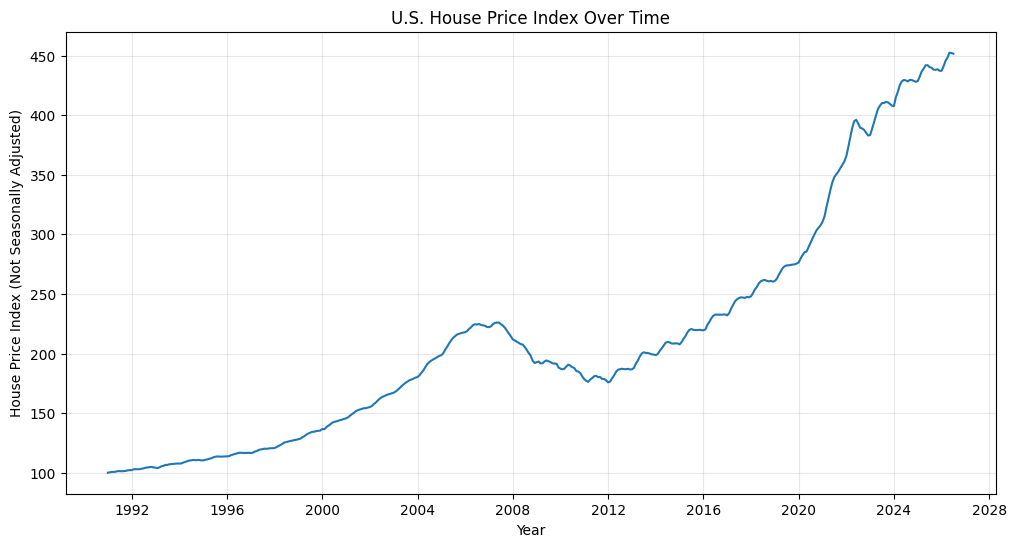

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    usa_monthly["date"],
    usa_monthly["index_nsa"]
)

plt.title("U.S. House Price Index Over Time")
plt.xlabel("Year")
plt.ylabel("House Price Index (Not Seasonally Adjusted)")
plt.grid(True, alpha=0.3)

plt.show()

The U.S. House Price Index shows a clear long-term increase in home values from 1991 to 2026. The index increased steadily throughout the 1990s and early 2000s before reaching a peak in the mid-2000s. This was followed by a noticeable decline that continued into the early 2010s. After this decline, the index began to recover and continued increasing throughout the remainder of the decade.

One of the most noticeable changes occurs after 2020, when the index rises much more rapidly than during most previous periods. Although there are some short-term fluctuations, the index reaches its highest levels near the end of the dataset. Overall, the visualization shows that U.S. housing values have experienced substantial long-term growth, while also demonstrating that housing markets can experience periods of decline and volatility.

In [26]:
divisions = [
    "East North Central Division",
    "East South Central Division",
    "Middle Atlantic Division",
    "Mountain Division",
    "New England Division",
    "Pacific Division",
    "South Atlantic Division",
    "West North Central Division",
    "West South Central Division"
]

regional_monthly = df[
    (df["place_name"].isin(divisions)) &
    (df["hpi_type"] == "traditional") &
    (df["hpi_flavor"] == "purchase-only") &
    (df["frequency"] == "monthly")
].copy()

regional_monthly["date"] = pd.to_datetime(
    dict(
        year=regional_monthly["yr"],
        month=regional_monthly["period"],
        day=1
    )
)

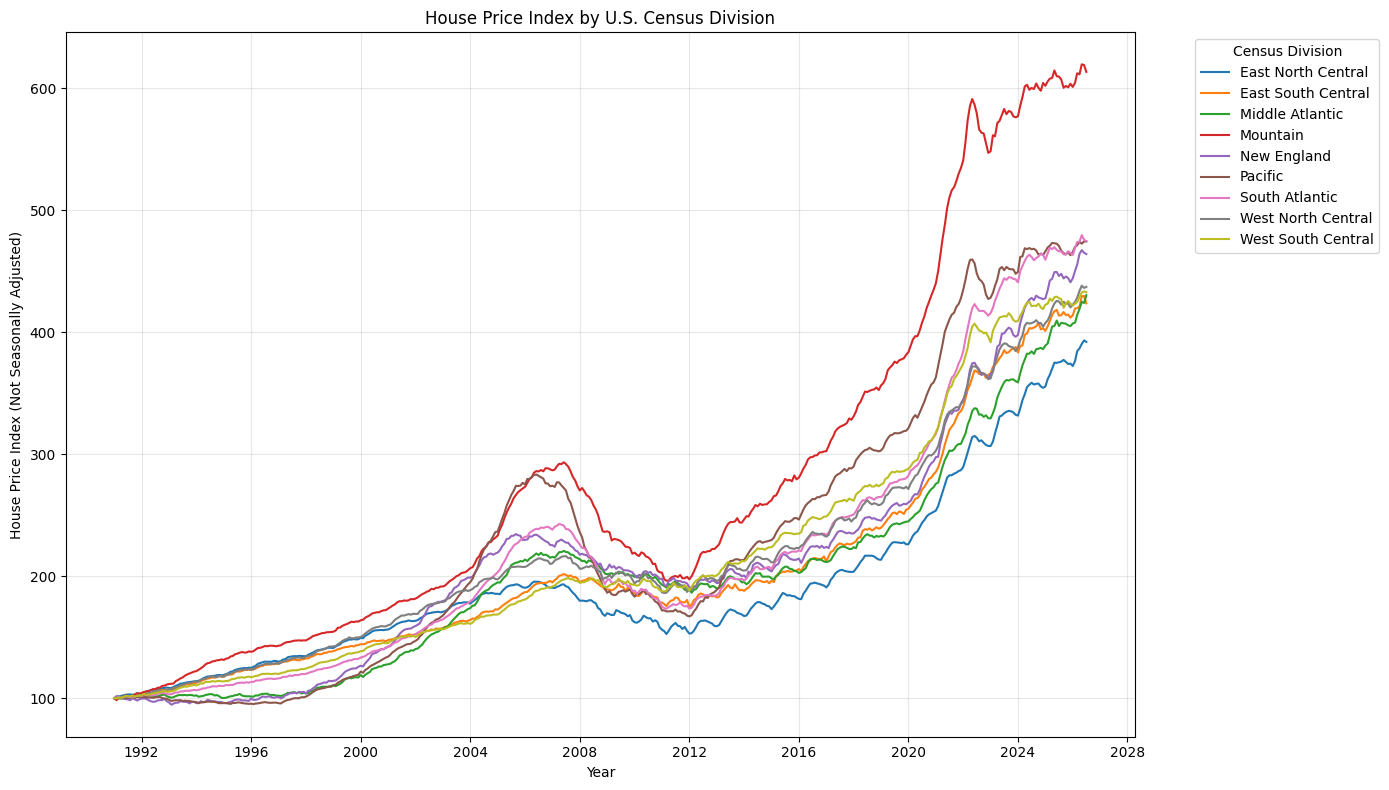

In [27]:
plt.figure(figsize=(14, 8))

for division in divisions:
    division_data = regional_monthly[
        regional_monthly["place_name"] == division
    ]

    plt.plot(
        division_data["date"],
        division_data["index_nsa"],
        label=division.replace(" Division", "")
    )

plt.title("House Price Index by U.S. Census Division")
plt.xlabel("Year")
plt.ylabel("House Price Index (Not Seasonally Adjusted)")
plt.legend(title="Census Division", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

The regional comparison shows that house price trends vary considerably across different parts of the United States. Although all nine Census Divisions show long-term growth, some regions experienced much larger increases than others. The **Mountain Division** stands out with the highest House Price Index near the end of the dataset and shows particularly rapid growth in recent years.

The graph also shows that many regions experienced a decline following their mid-to-late-2000s peaks before beginning to recover during the 2010s. After 2020, house price indexes increased rapidly across all nine divisions, although the size of these increases differed by region. These differences demonstrate why geographic location is an important factor to consider when evaluating real estate markets and potential investment opportunities.

# Part III: Expanding Your Investment Knowledge

Additional Dataset: Zillow Observed Rent Index (ZORI)
The Zillow Observed Rent Index (ZORI) would be a useful additional dataset for evaluating potential real estate investments. ZORI measures typical market rents across different geographic areas and tracks changes in rental prices over time. This information would be useful to a real estate investor because property appreciation is not the only factor to consider when evaluating an investment. The amount of rental income that a property could potentially generate is also important.
ZORI complements the FHFA House Price Index because the two datasets provide information about different parts of the housing market. The FHFA data shows how home values have changed over time, while ZORI provides information about rental prices. Comparing the two could help an investor determine whether areas experiencing increases in home values are also experiencing increases in rents, providing a more complete understanding of a local real estate market.
Dataset: Zillow Observed Rent Index (ZORI) - Metro, All Homes + Multifamily, Smoothed, Monthly
Source: Zillow Research
Dataset Link: https://files.zillowstatic.com/research/public_csvs/zori/Metro_zori_uc_sfrcondomfr_sm_month.csv

# Key Findings
This analysis shows that U.S. housing prices have generally increased over the long term, although the growth has not been consistent across every time period or geographic region. The national House Price Index shows periods of growth, decline, and recovery, with particularly rapid growth occurring after 2020. The regional comparison also demonstrates that housing markets can behave differently depending on location, with some Census Divisions experiencing much larger increases in the House Price Index than others.
From an investment perspective, these results show why both time and location are important when evaluating real estate markets. However, an increase in home values alone does not necessarily mean that a market is a good investment. Other factors, such as rental income, affordability, and local market conditions, should also be considered. Combining the FHFA House Price Index with additional information such as Zillow's rental data could therefore provide a more complete picture when evaluating potential real estate investments.